In [59]:
!pip install pandas seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [60]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import classification_report, balanced_accuracy_score

In [61]:
RANDOM_SEED = 37
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [62]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [63]:
base_path = "evaluation"
cenarios = ["zero-shot", "few-shot"]
dados = []

for cenario in cenarios:
    cenario_path = os.path.join(base_path, cenario)
    
    for root, dirs, files in os.walk(cenario_path):
        for file in files:
            if file == "individual_metrics.json":
                file_path = os.path.join(root, file)
                
                with open(file_path, "r", encoding="utf-8") as f:
                    metrics = json.load(f)
                
                for modelo, valores in metrics.items():
                    dados.append({
                        "cenario": cenario,
                        "modelo": modelo,
                        **valores
                    })

df_individuals = pd.DataFrame(dados)

model_short_names = {
    'gemma-3-gaia-pt-br-4b-it': 'Gaia',
    'mixtral-8x7b-instruct': 'Mixtral',
    'sabia-3.1': 'Sabiá',
    'granite-3-3-8b-instruct': 'Granite',
    'gemini-2.5-flash': 'Gemini',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio',
    'kimi-k2-0905': 'Kimi-K2'
}

df_individuals['modelo'] = df_individuals['modelo'].apply(lambda model_name: model_short_names[model_name])
df_individuals.head(3)

,cenario,modelo,punchlines,comic_styles,texts_explanations
0,zero-shot,Gaia,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
1,zero-shot,Mixtral,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
2,zero-shot,Sabiá,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...


In [64]:
def expand_dict_column(df, dict_col):
    df = df.copy()
    df[dict_col] = df[dict_col].apply(
        lambda x: x if isinstance(x, list) else [x] if isinstance(x, dict) else []
    )

    expanded_rows = []
    for _, row in df.iterrows():
        for item in row[dict_col]:
            if isinstance(item, dict):
                expanded_rows.append({
                    "scenario": row["cenario"],
                    **item
                })

    return pd.DataFrame(expanded_rows)

estilos_comicos_traduzidos = {
    "fun": "diversão",
    "humor": "humor ben.",
    "wit": "engenhosidade",
    "irony": "ironia",
    "nonsense": "absurdo",
    "cynicism": "cinismo",
    "satire": "sátira",                                                                             
    "sarcasm": "sarcasmo"                                                                                       
}

df_punchlines = expand_dict_column(df_individuals, "punchlines")
df_comic_styles = expand_dict_column(df_individuals, "comic_styles")
df_comic_styles['comic_style'] = df_comic_styles['comic_style'].apply(lambda style: estilos_comicos_traduzidos.get(style, style))                                                                                       
df_texts_explanations = expand_dict_column(df_individuals, "texts_explanations")
df_texts_explanations['agreement_level'] = df_texts_explanations['judge_model_results'].apply(lambda judge_model_result: int(judge_model_result['nivel_concordancia']))

### Erros e acertos em comum 

In [65]:
WORSE_PUNCHLINES_THRESHOLD = 0.4

##### Punchlines Identification

In [66]:
df_punchlines_worse = df_punchlines[
    (df_punchlines['dice_similarity'] <= WORSE_PUNCHLINES_THRESHOLD) |
    (df_punchlines['dice_similarity'].isna())]
df_punchlines_better = df_punchlines[(df_punchlines['dice_similarity'] >= 0.9) & (df_punchlines['dice_similarity'] < 1)]

In [67]:
df_punchlines_worse.columns

Index(['scenario', 'video_url', 'model_name', 'humorous_text', 'prompt',
       'model_punchlines', 'annotated_punchlines', 'raw_model_output',
       'cleaned_prediction', 'formatted_model_punchlines', 'dice_similarity',
       'is_original_format_valid', 'is_after_treatment_valid'],
      dtype='object')

In [68]:
models = ['gemma-3-gaia-pt-br-4b-it', 'gervasio-7b-portuguese-ptbr-decoder', 'deepseek-r1-0528-qwen3-8b']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gemma-3-gaia-pt-br-4b-it
Few-shot: 269 casos
Zero-shot: 187 casos
---
MODELO gervasio-7b-portuguese-ptbr-decoder
Few-shot: 475 casos
Zero-shot: 475 casos
---
MODELO deepseek-r1-0528-qwen3-8b
Few-shot: 422 casos
Zero-shot: 462 casos
---
MODELO gemma-3-gaia-pt-br-4b-it
SCENARIO: few-shot
CLEANED PREDICTIONS:

["Você explanta",
"Você bota água no copo, faz... GUT GUT GUT",
"Você bebe umas golada rea feia, né? GLOC GLOC GLOC",
"O estômago você escuta fazer... TOIM OIM OIM OIM OIM"]

ACTUAL PUNCHLINES:
Era mais porque ele tinha as coisas mesmo.;  Vocês sabem que um dia no gelado é um luxo pra gente.;  E dá o diabo de um guardanapo, velho, pra gente se engolir quando a gente vai... Nunca cobre a pessoa toda. Só vai até nos peitos. Você tem que ficar sacrificando os pés uma hora, a cabeça um pouquinho, às vezes fica...; Dá dez e meia, tu fala, ninguém almoça não nessa casa, não?; Você tá andando dentro de casa, o osso estala, pá! Você explanta. Você bota água no copo, faz... GUT GUT GU

In [69]:
models = ['gpt-4', 'gemini-2.5-flash', 'sabia-3.1']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gpt-4
Few-shot: 34 casos
Zero-shot: 26 casos
---
MODELO gemini-2.5-flash
Few-shot: 43 casos
Zero-shot: 65 casos
---
MODELO sabia-3.1
Few-shot: 98 casos
Zero-shot: 59 casos
---
MODELO gpt-4
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["A diferença entre o Silvio Santos e o Scooby Doo? Não? Um deles é um cachorro, Júnior.",
"Ah, vá se fude! Pô, todo mundo riu e tá jogando. Vai pra porra!"]
ACTUAL PUNCHLINES:
Um deles é um cachorro, Júnior. Como é que você não sabe? Tem muitas, tem muitas! É muito simples acertar essa, Júnior. 
---
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Pousou em cima do seu telhado, o homem desceu em cima do seu telhado e ficou em pé lá. O telhado assim, hein?", "Joca, você precisava ver, Joca. Todo suado, desceu, me viu assim na janela e falou assim: 'o senhor me conseguiria um copo d'água?' Eu não sei, eu não sei."]
ACTUAL PUNCHLINES:
o senhor me conseguiria um copo d'água?
---
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["É porque a gente cria expectativa quando f

In [70]:
models = ['gpt-4', 'gemini-2.5-flash', 'sabia-3.1']

df_punchlines_better

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_better[(df_punchlines_better['model_name'] == model) & (df_punchlines_better['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_better[(df_punchlines_better['model_name'] == model) & (df_punchlines_better['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    better_examples = df_punchlines_better[df_punchlines_better['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = better_examples['cleaned_prediction']
    actual_punchlines = better_examples['annotated_punchlines']
    scenario = better_examples['scenario']

    for i in range(len(better_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gpt-4
Few-shot: 41 casos
Zero-shot: 52 casos
---
MODELO gemini-2.5-flash
Few-shot: 49 casos
Zero-shot: 41 casos
---
MODELO sabia-3.1
Few-shot: 16 casos
Zero-shot: 23 casos
---
MODELO gpt-4
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Doutor Ricardo, parece. O cara que cuida da saúde bucal. Lourdes, merendeira da escola da gente. Lourdes. Parece. Não parece? Maria de Lourdes, filha da Lourdes, trabalha na escola também, junto com ela.",
"Você não pode chegar no hospital e o nome do médico é Joilson. Não pode. Você chega no hospital com a perna arrancada, o nome do médico é Joilson, ele vai remendar com cimento, porque Joilson é pedreiro.",
"Fala, Joilson, remenda minha perna. É agora, meu patrão. Vai fazer assim, ó. Assim, na perninha, assim, ó.",
"Porque o piloto, quando ele é bom, o nome dele é foda junto com ele. O cara fala: atenção, senhores passageiros, quem fala é o comandante Arnold Schwarzenegger, né? Eu não boto nem cinto, me sinto seguro com aquele cara ali."]
ACTUAL PUNC

##### Comic Styles Classification

In [71]:
df_comic_styles['model_name'] = df_comic_styles['model_name'].apply(lambda model_name: model_short_names[model_name])
df_comic_styles['model_name'].unique()

array(['Gaia', 'Mixtral', 'Sabiá', 'Granite', 'Gemini', 'GPT-4',
       'Gervasio', 'LLaMA', 'Kimi-K2', 'DeepSeek'], dtype=object)

/tmp/ipykernel_72962/3885627232.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df_merged.pivot_table(


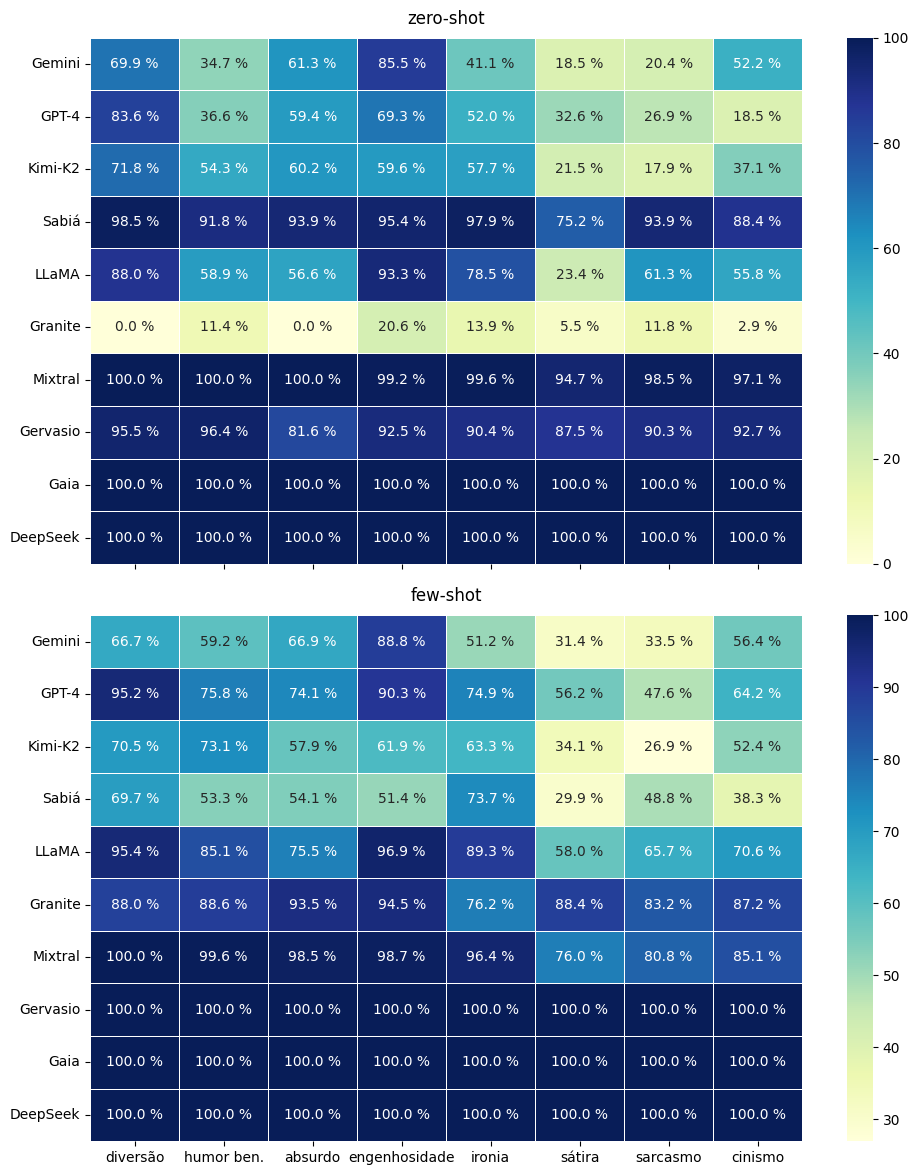

In [72]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
    'Mixtral',
    'Gervasio',
    'Gaia',
    'DeepSeek'
]

comic_style_order = [
    'diversão', 
    'humor ben.', 
    'absurdo', 
    'engenhosidade', 
    'ironia', 
    'sátira', 
    'sarcasmo',       
    'cinismo'
]

df_counts_1 = df_comic_styles[df_comic_styles['pred_label'] == 1]
df_counts_1 = df_counts_1.groupby(['scenario', 'model_name', 'comic_style']).size().reset_index(name='count_correct')

df_counts_total = df_comic_styles.groupby(['scenario', 'model_name', 'comic_style']).size().reset_index(name='count_total')

df_merged = pd.merge(df_counts_1, df_counts_total, on=['scenario', 'model_name', 'comic_style'], how='right').fillna(0)

df_merged['percentage'] = (df_merged['count_correct'] / df_merged['count_total']) * 100

df_merged['model_name'] = pd.Categorical(df_merged['model_name'], categories=model_order, ordered=True)

df_merged['comic_style'] = pd.Categorical(df_merged['comic_style'], categories=comic_style_order, ordered=True)

pivot_data = df_merged.pivot_table(
    index='model_name',
    columns=['scenario', 'comic_style'],
    values='percentage',
    fill_value=0 
)

pivot_data = pivot_data.reindex(model_order)

scenarios = df_comic_styles['scenario'].unique()
fig, axes = plt.subplots(len(scenarios), 1, figsize=(10, 12), sharex=False, sharey=True) 
plt.suptitle('', fontsize=16, y=1.02)

if len(scenarios) == 1:
    axes = [axes]

for i, scenario in enumerate(scenarios):
    
    heatmap_data = pivot_data.xs(scenario, level='scenario', axis=1)
    
    sns.heatmap(
        heatmap_data,
        ax=axes[i],        
        annot=True,        
        fmt=".1f",         
        cmap="YlGnBu",     
        linewidths=.5,
        cbar_kws={'label': ''} 
    )
    
    for t in axes[i].texts: 
        t.set_text(t.get_text() + " %")
    
    axes[i].set_title(f'{scenario.lower()}', pad=10) 
    
    if i == len(scenarios) - 1:
        axes[i].set_xlabel('') 
        axes[i].tick_params(axis='x', rotation=0) 
    else:
        axes[i].set_xlabel('')
        axes[i].set_xticklabels([]) 
    
    axes[i].set_ylabel('') 

plt.tight_layout()
plt.savefig(os.path.join(visus_path, 'comic_styles_heatmap_by_scenario_vertical.png'), dpi=300, bbox_inches='tight')
plt.show()

In [73]:
df = df_comic_styles.copy()
rows = []

for (model, scenario, style), group in df.groupby(['model_name', 'scenario', 'comic_style']):
    y_true = group['true_label']
    y_pred = group['pred_label']
    
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    rows.append({
        'model_name': model,
        'scenario': scenario,
        'comic_style': style,
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'balanced_accuracy': bal_acc
    })

results = pd.DataFrame(rows)

In [74]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite', 
    """ 'Gaia',
    'Mixtral',
    'DeepSeek',
    'Gervasio'"""
]

results['model_name'] = pd.Categorical(results['model_name'], categories=model_order, ordered=True)

/tmp/ipykernel_72962/15416107.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_72962/15416107.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_72962/15416107.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_72962/15416107.py:10: FutureWarning: The default value of 

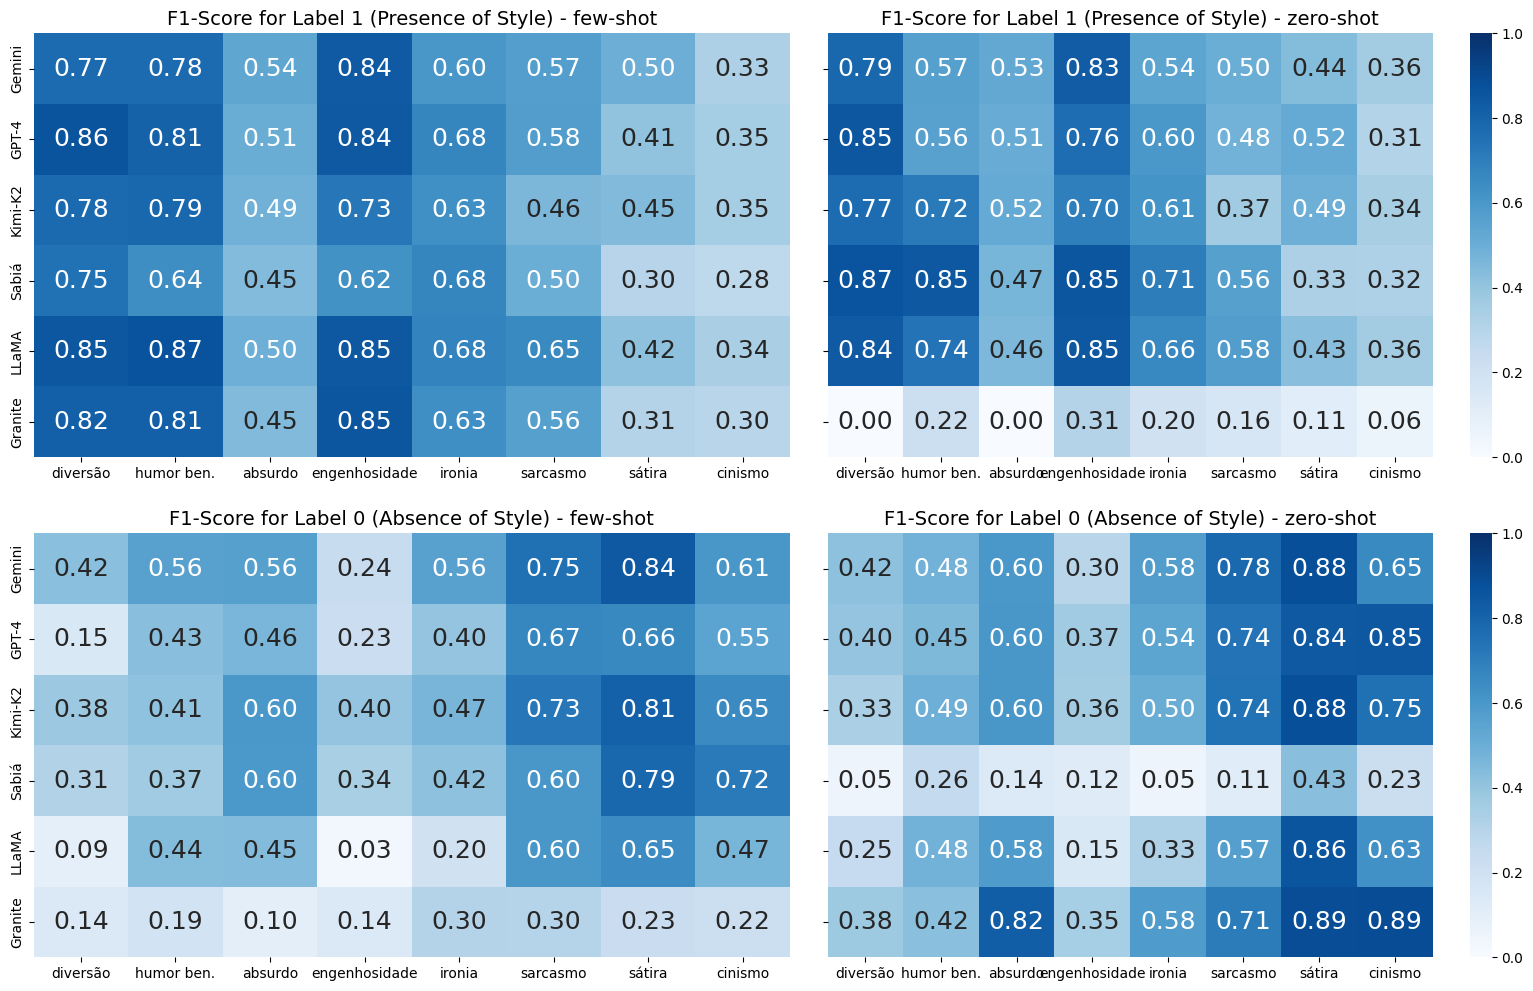

In [75]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharey=True)
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]
scenarios = results['scenario'].unique()
style_order = ['diversão', 'humor ben.', 'absurdo', 'engenhosidade', 'ironia', 'sarcasmo', 'sátira', 'cinismo']

for row_idx, (f1_class, title) in enumerate(f1_info):
    for col_idx, scenario in enumerate(scenarios):
        ax = axes[row_idx, col_idx]

        pivot = results[results['scenario'] == scenario].pivot_table(
            index='model_name', columns='comic_style', values=f1_class, aggfunc='mean'
        )
        
        pivot = pivot.reindex(columns=style_order)

        sns.heatmap(
            pivot,
            annot=True,
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            fmt=".2f",
            annot_kws={'size': 18},
            cbar=(col_idx == 1)
        )
        
        ax.set_title(f'F1-Score for {title} - {scenario}', fontsize=14)
        ax.set_xlabel('', fontsize=16) 
        if col_idx == 0:
            ax.set_ylabel('', fontsize=16)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', labelsize=10, rotation=0)
        ax.tick_params(axis='y', labelsize=10)

plt.subplots_adjust(hspace=0.18, wspace=0.05)

plt.savefig(
    os.path.join(visus_path, "comic_styles_f1_individuals.png"), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [76]:
comic_styles = df_comic_styles['comic_style'].unique()
for style in comic_styles:
    df_name_worse = f"df_{style}_worse"
    df_name_better = f"df_{style}_better"
    globals()[df_name_worse] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 0)]
    globals()[df_name_better] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 1)]

##### Matriz de co-ocorrência

In [77]:
original_data = pd.read_csv('./data/brazilian_ne_annotated_humorous_texts.csv')
original_data.head(2)

,video_url,video_title,publish_date,brazilian_state,text_origin,corrected_transcription,specific_contexts,punchlines,fun,humor,nonsense,wit,irony,satire,sarcasm,cynicism,joke_explanation
0,https://www.youtube.com/shorts/Xcve3ifSxWg?fea...,O CARA PUXOU A PISTOLA PRA MIM E EU... - EMERS...,"Dec 6, 2022",Ceará,Podcast,"Humorista: O cara me chamou falou aqui ó, puxo...","""Ovo virado"" é uma gíria pra indicar que algué...","Eu falei, vai buscar mais. Isso aí não dá nem ...",1,1,0,0,1,0,1,0,"O humorista narra uma cena tensa, porém cômica..."
1,https://www.youtube.com/shorts/QV80EKixLYc?fea...,Cachaçaaa😂😂 - Flavio Andradde - #shorts,"Oct 30, 2024",Pernambuco,Stand-up,Humorista: Quem já passou algumas coisas muito...,Record é uma rede de televisão comercial abert...,E ele tem a cara de pau de dizer era Cerveja!;...,1,1,0,1,0,1,1,0,O humorista desdenha da marca Crystal a partir...


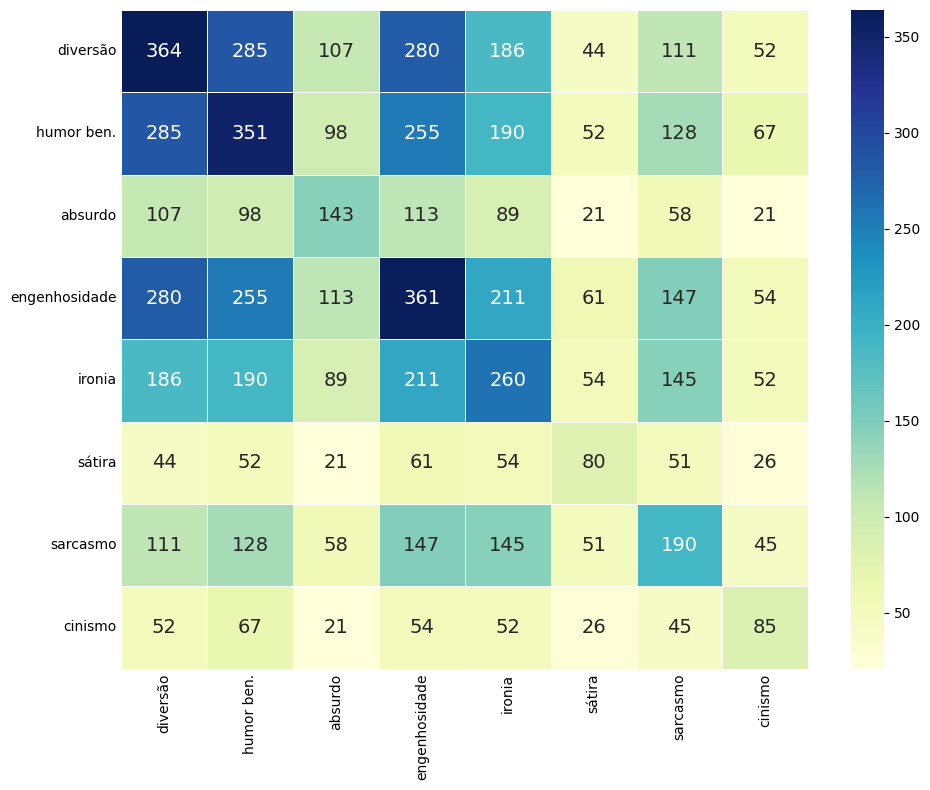

In [78]:
comic_styles = [
    'diversão', 'humor ben.', 'absurdo', 'engenhosidade', 'ironia', 'sátira', 'sarcasmo', 'cinismo'
]

original_data.rename(columns=estilos_comicos_traduzidos, inplace=True)
data_styles = original_data[comic_styles]
cooccurrence_matrix = data_styles.T.dot(data_styles)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cooccurrence_matrix, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu', 
    linewidths=.5,
    cbar_kws={'label': ''},
    annot_kws={'fontsize': 14}
)

ax = plt.gca() 

ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('./visualizations/comic_styles.png')

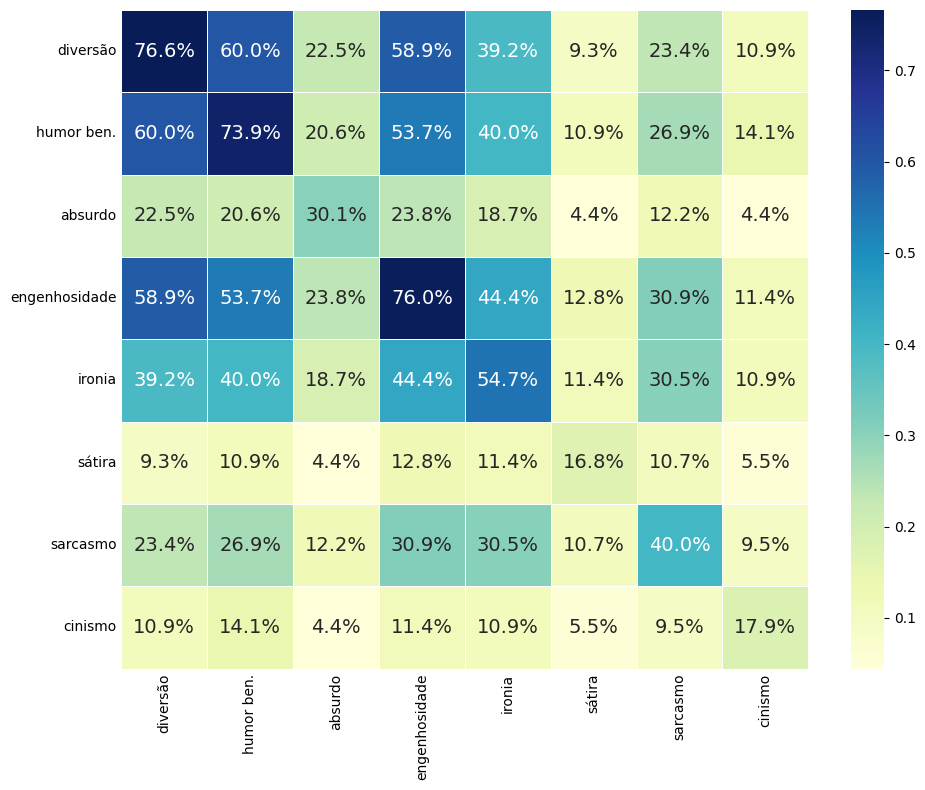

In [ ]:
comic_styles = [
    'diversão', 'humor ben.', 'absurdo', 'engenhosidade', 'ironia', 'sátira', 'sarcasmo', 'cinismo'
]

data_styles = original_data[comic_styles]
cooccurrence_matrix = data_styles.T.dot(data_styles)

total_casos = len(data_styles)
cooccurrence_matrix_pct = cooccurrence_matrix / total_casos

plt.figure(figsize=(10, 8))
sns.heatmap(
    cooccurrence_matrix_pct,
    annot=True, 
    fmt='.1%',              
    cmap='YlGnBu', 
    linewidths=.5,
    cbar_kws={'label': ''},
    annot_kws={'fontsize': 14}
)

ax = plt.gca()
ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('./visualizations/comic_styles_distribution.png')

In [80]:
df_comic_styles = df_comic_styles.copy()[df_comic_styles['model_name'].isin(model_order)]
df_comic_styles['model_name'].unique()

array(['Sabiá', 'Granite', 'Gemini', 'GPT-4', 'LLaMA', 'Kimi-K2'],
      dtype=object)

In [81]:
df_erros = df_comic_styles[df_comic_styles['is_correct'] == 0].copy()
distintos = (
    df_erros.groupby(['humorous_text', 'comic_style'])['model_name']
    .nunique()
    .reset_index(name='n_modelos_distintos')
)

casos_dificeis = distintos[distintos['n_modelos_distintos'] >= 4]
df_final = pd.merge(df_erros, casos_dificeis, on=['humorous_text', 'comic_style'])

contagem_total = (
    df_final.groupby(['comic_style', 'true_label'])['humorous_text']
    .nunique()
    .unstack(fill_value=0)
    .rename(columns={0: 'total_L0', 1: 'total_L1'})
)

def sample_cases(gp):
    texts_label_1 = gp[gp['true_label'] == 1]['humorous_text'].unique()
    texts_label_0 = gp[gp['true_label'] == 0]['humorous_text'].unique()
    
    s_label_1 = pd.Series(texts_label_1).sample(n=min(len(texts_label_1), 20), random_state=RANDOM_SEED)
    s_label_0 = pd.Series(texts_label_0).sample(n=min(len(texts_label_0), 20), random_state=RANDOM_SEED)

    selected_texts = pd.concat([s_label_1, s_label_0])

    return gp[gp['humorous_text'].isin(selected_texts)]

df_amostra = (
    df_final.groupby(['comic_style'], group_keys=False)
    .apply(sample_cases)
)

for estilo, grupo in df_amostra.groupby('comic_style'):
    total_l0 = contagem_total.loc[estilo, 'total_L0']
    total_l1 = contagem_total.loc[estilo, 'total_L1']
    total_estilo = total_l0 + total_l1
    
    print(f"\n" + "█"*110)
    print(f" ESTILO CÔMICO: {estilo.upper()}")
    print(f" TOTAL DE CASOS DIFÍCEIS ENCONTRADOS: {total_estilo} (Label 1: {total_l1} | Label 0: {total_l0})")
    print(f" AMOSTRA ATUAL: {grupo['humorous_text'].nunique()} casos")
    print("█"*110)
    
    for texto, sub_grupo in grupo.sort_values('true_label', ascending=False).groupby('humorous_text', sort=False):
        label_real = sub_grupo['true_label'].iloc[0]
        total_distintos = sub_grupo['n_modelos_distintos'].iloc[0]
        
        erros_zs = sub_grupo[sub_grupo['scenario'] == 'zero-shot']['model_name'].nunique()
        erros_fs = sub_grupo[sub_grupo['scenario'] == 'few-shot']['model_name'].nunique()
        
        print(f"\nTEXTO: {texto}")
        print(f"LABEL REAL: {label_real} | TOTAL MODELOS DISTINTOS QUE ERRARAM: {total_distintos}")
        print(f"ERROS NO ZERO-SHOT: {erros_zs} | ERROS NO FEW-SHOT: {erros_fs}")
        
        for cenario in ['zero-shot', 'few-shot']:
            modelos_cenario = sub_grupo[sub_grupo['scenario'] == cenario]
            if not modelos_cenario.empty:
                print(f"   → Erros em {cenario.upper()}:")
                for _, row in modelos_cenario.iterrows():
                    print(f"       • {row['model_name']:<15} | Predição: {row['pred_label']}")
        
        print("-" * 80)

/tmp/ipykernel_72962/1606325412.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_cases)



██████████████████████████████████████████████████████████████████████████████████████████████████████████████
 ESTILO CÔMICO: ABSURDO
 TOTAL DE CASOS DIFÍCEIS ENCONTRADOS: 300 (Label 1: 38 | Label 0: 262)
 AMOSTRA ATUAL: 40 casos
██████████████████████████████████████████████████████████████████████████████████████████████████████████████

TEXTO: Eu acho muito engraçado os cara que dança na academia. Porque os cara que dança tem um mundo particular. Bota o fone de ouvido e fica no espelho. Parece que quando ele bota o fone de ouvido, cria-se um mundo particular na mente dele. Que parece que a academia vira um chroma key e tem um diretor no fone. Quando eu soltar a música, eu não quero ver ninguém parar. Uma vez eu tava na academia e o cara mais no peito aqui deitado no supino. Tem uns que geme, né? Ele soltou o peso aqui na barba e... Então eu cheguei nele e falei: faltam quantas aí? Ele: três. Falei: aproveita bota Psirico, Molejo e Harmonia do Samba.
LABEL REAL: 1 | TOTAL MODELOS D

##### Humor Reasoning

In [82]:
WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_LEVEL = 4

In [83]:
df_explanations_worse = df_texts_explanations[df_texts_explanations['agreement_level'] <= WORSE_EXPLANATIONS_THRESHOLD]
df_explanations_better = df_texts_explanations[df_texts_explanations['agreement_level'] == BETTER_EXPLANATIONS_LEVEL]

##### Piores casos dos piores modelos

In [84]:
models = ['mixtral-8x7b-instruct', 'deepseek-r1-0528-qwen3-8b', 'gervasio-7b-portuguese-ptbr-decoder']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_explanations_worse[(df_explanations_worse['model_name'] == model) & (df_explanations_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_explanations_worse[(df_explanations_worse['model_name'] == model) & (df_explanations_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_explanations_worse[df_explanations_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['model_text_explanation']
    actual_explanations = worse_examples['annotated_text_explanation']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL EXPLANATIONS:')
        print(actual_explanations.iloc[i])
        print('---')

MODELO mixtral-8x7b-instruct
Few-shot: 160 casos
Zero-shot: 174 casos
---
MODELO deepseek-r1-0528-qwen3-8b
Few-shot: 359 casos
Zero-shot: 256 casos
---
MODELO gervasio-7b-portuguese-ptbr-decoder
Few-shot: 430 casos
Zero-shot: 435 casos
---
MODELO mixtral-8x7b-instruct
SCENARIO: zero-shot
CLEANED PREDICTIONS:

O humor presente no texto é resultado da interação entre o humorista e o espectador, com o humorista utilizando a repetição e a ironia para criar um efeito cômico. A repetição do nome "Alex" e a pergunta sobre o plural do nome servem para criar um efeito de surpresa e desconforto no espectador, enquanto a ironia é utilizada para questionar a singularidade do nome "Alex" e sua suposta relação com o nome "Alexia". Além disso, a brincadeira com o plural do nome "Alex" é uma referência ao gênero feminino, o que pode ser interpretado como uma piada sobre o gênero.
ACTUAL EXPLANATIONS:
O humorista faz uma relação divertida entre o plural de Alex, que ele acha ser "Alexias", e a Alexa, I

##### Piores casos dos melhores modelos

In [85]:
models = ['sabia-3.1', 'gemini-2.5-flash', 'gpt-4']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_explanations_worse[(df_explanations_worse['model_name'] == model) & (df_explanations_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_explanations_worse[(df_explanations_worse['model_name'] == model) & (df_explanations_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_explanations_worse[df_explanations_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['model_text_explanation']
    actual_explanations = worse_examples['annotated_text_explanation']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL EXPLANATIONS:')
        print(actual_explanations.iloc[i])
        print('---')

MODELO sabia-3.1
Few-shot: 92 casos
Zero-shot: 81 casos
---
MODELO gemini-2.5-flash
Few-shot: 70 casos
Zero-shot: 31 casos
---
MODELO gpt-4
Few-shot: 81 casos
Zero-shot: 72 casos
---
MODELO sabia-3.1
SCENARIO: few-shot
CLEANED PREDICTIONS:
 O efeito cômico do texto humorístico se deve a uma série de elementos. Primeiro, há a expectativa criada pelo pai ao sugerir uma cor improvável, "azul siberiano", como resposta para o pedido da professora, o que inicialmente parece ser uma solução engenhosa para o problema do Dudu. Segundo, a brincadeira com o número 40, que implicitamente sugere que Dudu será um dos últimos a responder, o que pode dificultar sua escolha por uma cor original. Terceiro, o humor inesperado acontece quando o personagem Louro, ao invés de ser um nome comum, é usado como nome de um aluno e responde exatamente com a cor improvável sugerida pelo pai de Dudu, "azul siberiano". Isso subverte a expectativa do pai e do Dudu de que essa cor seria única. Por último, quando a pro

##### Casos quase ideais dos melhores modelos

In [86]:
models = ['gpt-4', 'gemini-2.5-flash', 'sabia-3.1']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_explanations_better[(df_explanations_better['model_name'] == model) & (df_explanations_better['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_explanations_better[(df_explanations_better['model_name'] == model) & (df_explanations_better['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    better_examples = df_explanations_better[df_explanations_better['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = better_examples['model_text_explanation']
    actual_explanations = better_examples['annotated_text_explanation']
    scenario = better_examples['scenario']

    for i in range(len(better_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL EXPLANATIONS:')
        print(actual_explanations.iloc[i])
        print('---')

MODELO gpt-4
Few-shot: 113 casos
Zero-shot: 78 casos
---
MODELO gemini-2.5-flash
Few-shot: 97 casos
Zero-shot: 54 casos
---
MODELO sabia-3.1
Few-shot: 95 casos
Zero-shot: 95 casos
---
MODELO gpt-4
SCENARIO: few-shot
CLEANED PREDICTIONS:
O humor do texto vem da descrição exagerada do narrador de uma luta de boxe que ele participou. Ele usa uma voz dramática para retratar a luta como um ataque brutal, quase um "homicídio televisionado". Além disso, o texto brinca com a subversão das expectativas ao descrever seus socos na cara como algo de pouca preocupação ("Já quebrou, que é o nariz nos dias de hoje") e se retratando como vitorioso quando percebeu que seu oponente estava cansado. A imagem ridícula de ele, após ser atingido na orelha, procurando por lutadores famosos adiciona mais humor ao texto.
ACTUAL EXPLANATIONS:
O humorista narra sua luta contra o pugilista Popó e brinca que, para ele, a luta durou apenas três rounds, pois o restante foi, na verdade, uma "tentativa de homicídio", d